In [2]:
import utils_FaIR_JAX
import matplotlib.pyplot as plt

## Setup plots
plt.rcParams['figure.figsize'] = [12, 4]
plt.rcParams.update({'font.size': 16})
plt.rcParams.update({
  "text.usetex": True,
  "font.family": "sans-serif",
  "font.sans-serif": ["Helvetica Light"],
})

%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


## Calibrate JAX SCM using FaIRv2.0.0 outputs
To calibrate our simple climate model written in JAX (parameters and model structure chosen to reproduce FaIR, e.g., carbon cycle with four reservoirs), we first generate a set of single-forcing scenarios using the baseline FaIR model. We then use our inverse model to iteratively update our initial parameter guesses to reproduce the FaIR temperature response for each agent.

#### 1. CO<sub>2</sub> calibration

In [70]:
# Generate calibration dataset
agents = ['CO2']
emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = utils_FaIR_JAX.generate_calib_data(agents)
len_hist = len(delT_dict_calib_FaIR['historical'])

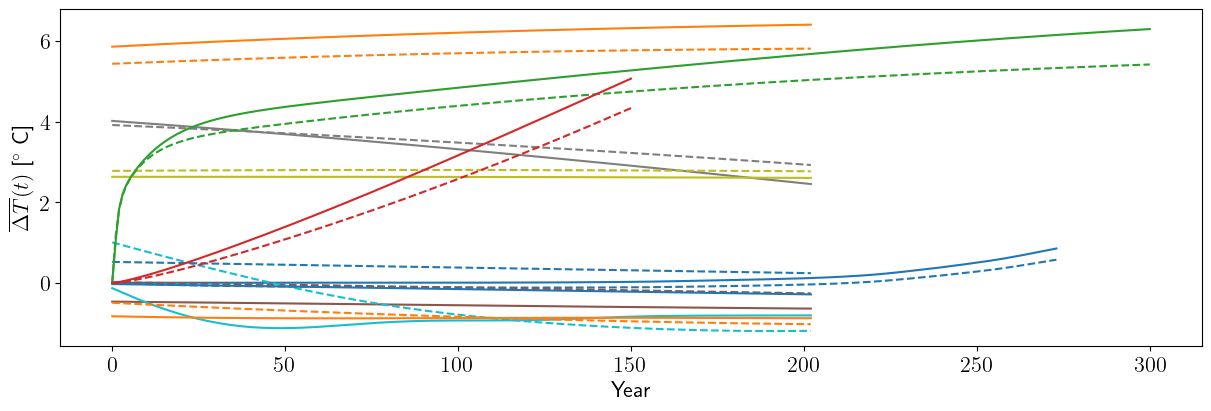

In [71]:
# Optional: plot calibration data
utils_FaIR_JAX.plot_FaIR_v_JAX(delT_dict_calib_FaIR, delT_dict_calib_JAX)

In [68]:
# Simulation parameters
dt = 0.1
n_steps = 10
filepath = 'data/JAX_calibration/calib_CO2_only2.pkl'

# Generate default parameters and then optimize
theta0 = utils_FaIR_JAX.make_theta0(utils_FaIR_JAX.DEFAULT_PARAMS)
theta_opt, loss_value = utils_FaIR_JAX.calibrate_inverse(filepath, emis_dict_calib_JAX, delT_dict_calib_FaIR, theta0, dt, n_steps, target='CO2')

step    0 | loss_avg = 0.25152
Final loss_avg: 0.24228039383888245


#### 2. CH<sub>4</sub> calibration

In [72]:
# Generate calibration dataset
agents = ['CH4']
emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = utils_FaIR_JAX.generate_calib_data(agents)
len_hist = len(delT_dict_calib_FaIR['historical'])

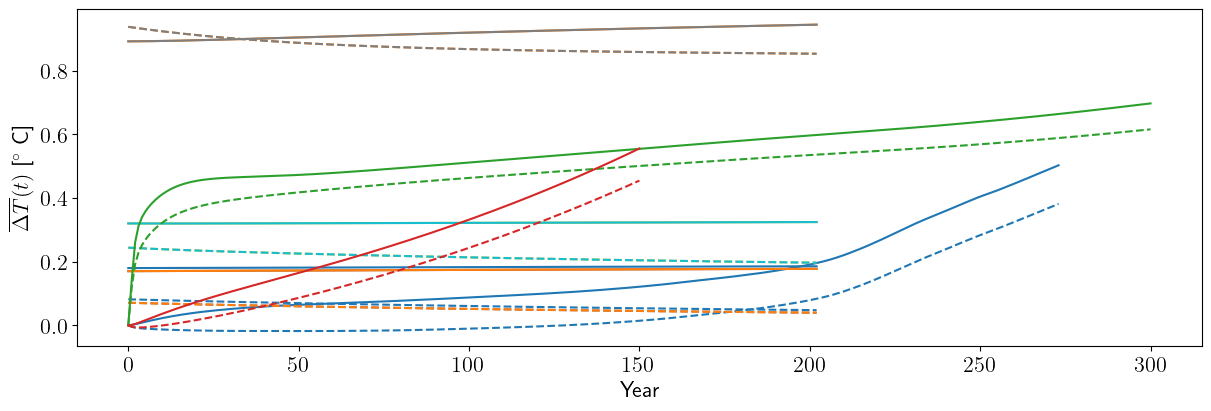

In [73]:
# Optional: plot calibration data
utils_FaIR_JAX.plot_FaIR_v_JAX(delT_dict_calib_FaIR, delT_dict_calib_JAX)

In [74]:
# Simulation parameters
dt = 0.1
n_steps = 10
filepath = 'data/JAX_calibration/calib_CH4_only.pkl'

# Generate default parameters and then optimize
theta0 = utils_FaIR_JAX.make_theta0(utils_FaIR_JAX.DEFAULT_PARAMS)
theta_opt, loss_value = utils_FaIR_JAX.calibrate_inverse(filepath, emis_dict_calib_JAX, delT_dict_calib_FaIR, theta0, dt, n_steps, target='CH4')

step    0 | loss_avg = 0.09858
Final loss_avg: 0.3581525683403015


#### 3. N<sub>2</sub>O calibration

In [62]:
# Generate calibration dataset
agents = ['N2O']
emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = utils_FaIR_JAX.generate_calib_data(agents)
len_hist = len(delT_dict_calib_FaIR['historical'])

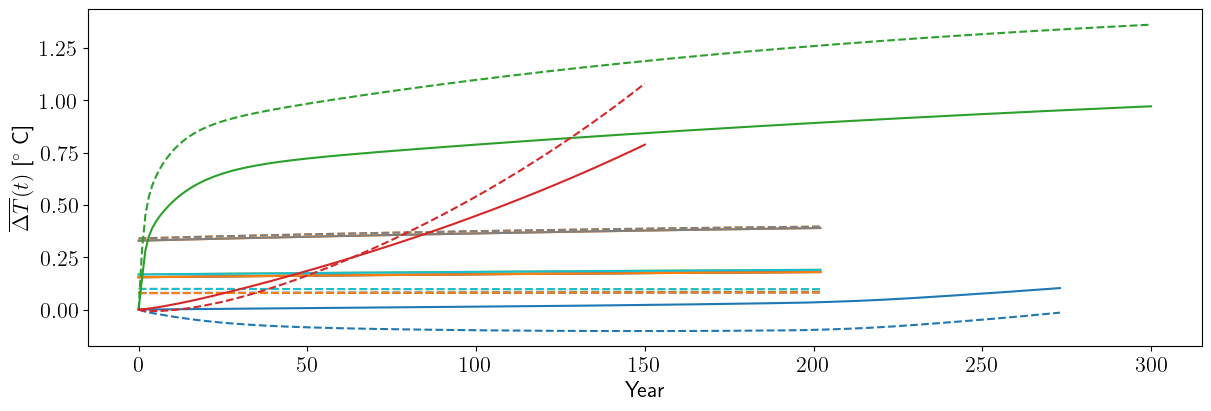

In [63]:
# Optional: plot calibration data
utils_FaIR_JAX.plot_FaIR_v_JAX(delT_dict_calib_FaIR, delT_dict_calib_JAX)

In [60]:
# Simulation parameters
dt = 0.1
n_steps = 10
filepath = 'data/JAX_calibration/calib_N2O_only.pkl'

# Generate default parameters and then optimize
theta0 = utils_FaIR_JAX.make_theta0(utils_FaIR_JAX.DEFAULT_PARAMS)
theta_opt, loss_value = utils_FaIR_JAX.calibrate_inverse(filepath, emis_dict_calib_JAX, delT_dict_calib_FaIR, theta0, dt, n_steps, target='N2O')

step    0 | loss_avg = 0.07085
Final loss_avg: 0.06770730018615723


#### 4. Sulfur and black carbon calibration
Both have to be completed simultaneously since they depend on the same set of parameters.

In [82]:
# Generate calibration dataset
agents = ['Sulfur','BC']
emis_dict_calib_FaIR, emis_dict_calib_JAX, delT_dict_calib_FaIR, delT_dict_calib_JAX = utils_FaIR_JAX.generate_calib_data(agents)
len_hist = len(delT_dict_calib_FaIR['historical'])

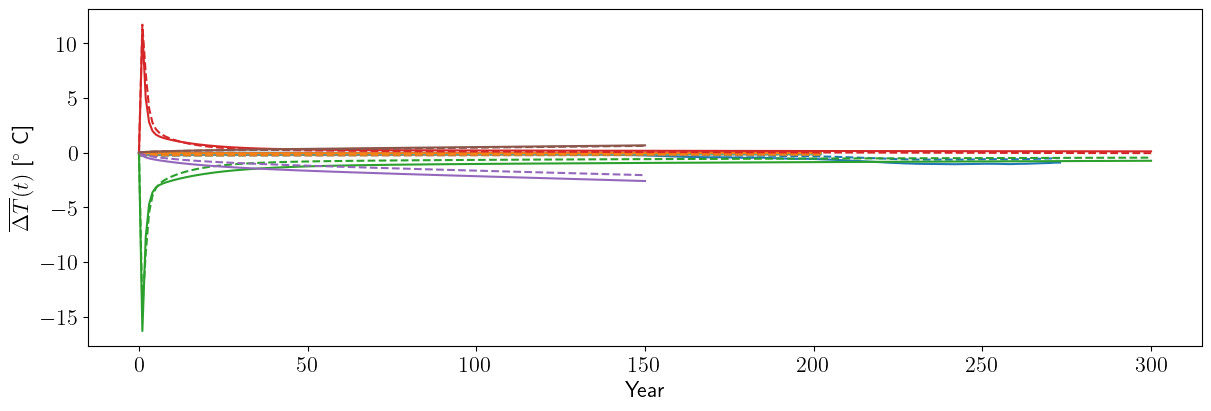

In [83]:
# Optional: plot calibration data
utils_FaIR_JAX.plot_FaIR_v_JAX(delT_dict_calib_FaIR, delT_dict_calib_JAX)

In [78]:
# Simulation parameters
dt = 0.1
n_steps = 10
filepath = 'data/JAX_calibration/calib_Sulfur_BC.pkl'

# Generate default parameters and then optimize
theta0 = utils_FaIR_JAX.make_theta0(utils_FaIR_JAX.DEFAULT_PARAMS)
theta_opt, loss_value = utils_FaIR_JAX.calibrate_inverse(filepath, emis_dict_calib_JAX, delT_dict_calib_FaIR, theta0, dt, n_steps, target='Aer')

step    0 | loss_avg = 0.11026
Final loss_avg: 0.10237575322389603
